In [1]:
%load_ext autoreload
%autoreload 2

import os
from pathlib import Path
import numpy as np
import pandas as pd

import geopandas as gpd
from shapely.geometry import Point
import rasterio

import matplotlib.pyplot as plt
import contextily as ctx

os.chdir("c:/Users/Administrator/Desktop/Uni Landau/Master/4. Semester/ACP4/ACP4")

from acp4.config.config import Config
config = Config()


## 1. Data availability and quality checks

In [101]:
from acp4.processing.concat_agrometeo_data import concat_agrometeo_data
from acp4.io.read_data import Data, read_camel_data, read_agro_data
from acp4.processing.process_data import rename_agro_data, align_climate_timeseries
from acp4.processing.check_data import (
    print_data_length, check_missing_values, check_duplicated_dates, 
    plot_flow_with_na, plot_flow_precip_temp
)

### Read and process data

In [102]:
concat_agrometeo_data()

df_discharge, df_camel = read_camel_data(
    timeseries_dir=config.timeseries_dir, 
    gauge_id=config.gauge_id
)

dfs_agro = read_agro_data(timeseries_dir=config.agrometeo_dir)
dfs_agro = rename_agro_data(data=dfs_agro)

data = Data(
    discharge= df_discharge,
    camel=df_camel,
    agro_herxheimweyher=dfs_agro["herxheimweyher_concat"],
    agro_steinweiler=dfs_agro["steinweiler_concat"]
)

data = align_climate_timeseries(data=data)

Files yet exists.


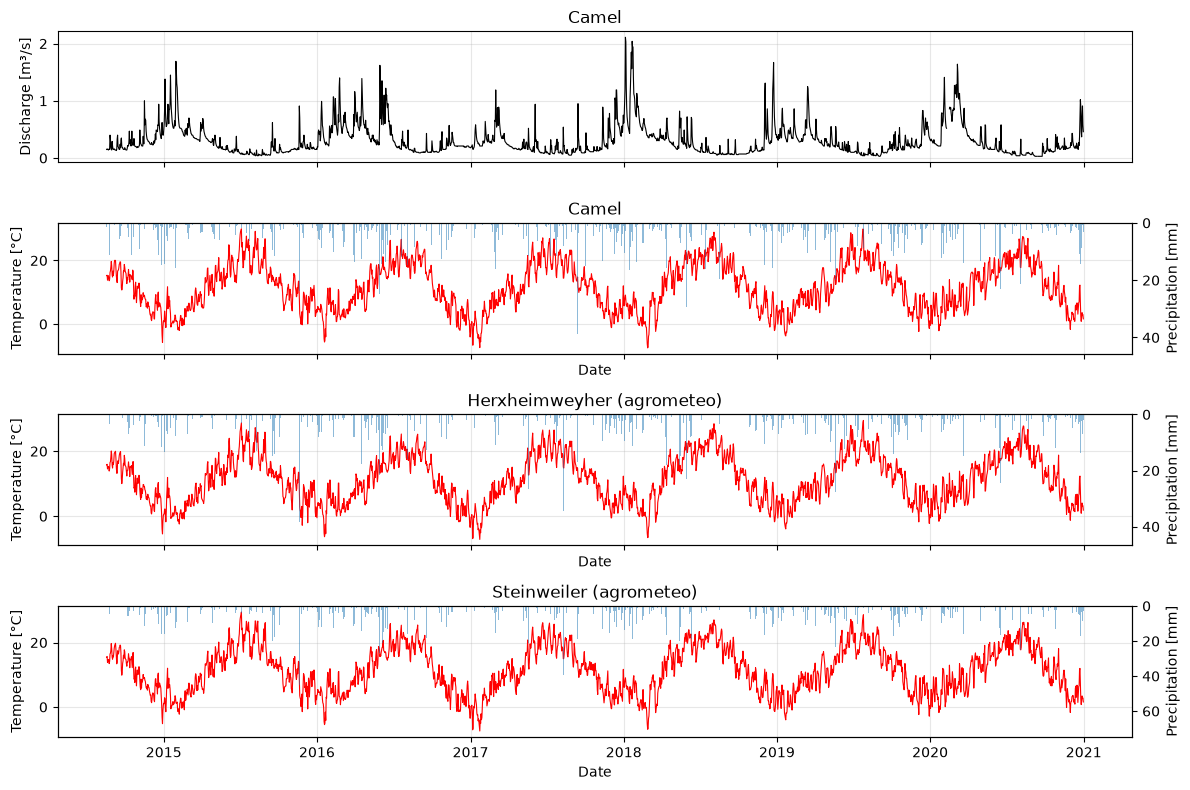

In [7]:
plot_flow_precip_temp(data=data)

### Quality checks

In [12]:
# Question 1.1
print_data_length(data=data)

Name: discharge
Length of available data: 2327 days 00:00:00
Period: 2014-08-18 00:00:00 - 2020-12-31 00:00:00
------------------------
Name: camel
Length of available data: 2327 days 00:00:00
Period: 2014-08-18 00:00:00 - 2020-12-31 00:00:00
------------------------
Name: agro_herxheimweyher
Length of available data: 2327 days 00:00:00
Period: 2014-08-18 00:00:00 - 2020-12-31 00:00:00
------------------------
Name: agro_steinweiler
Length of available data: 2327 days 00:00:00
Period: 2014-08-18 00:00:00 - 2020-12-31 00:00:00
------------------------


In [13]:
# Question 1.3
check_missing_values(data=data)

Name: discharge
Number of NAs:
discharge_vol_obs     8
discharge_spec_obs    8
water_level_obs       3
dtype: int64
Percentage of NAs:
discharge_vol_obs     0.34
discharge_spec_obs    0.34
water_level_obs       0.13
dtype: float64%
------------------------
Name: camel
No missing values.
------------------------
Name: agro_herxheimweyher
No missing values.
------------------------
Name: agro_steinweiler
No missing values.
------------------------


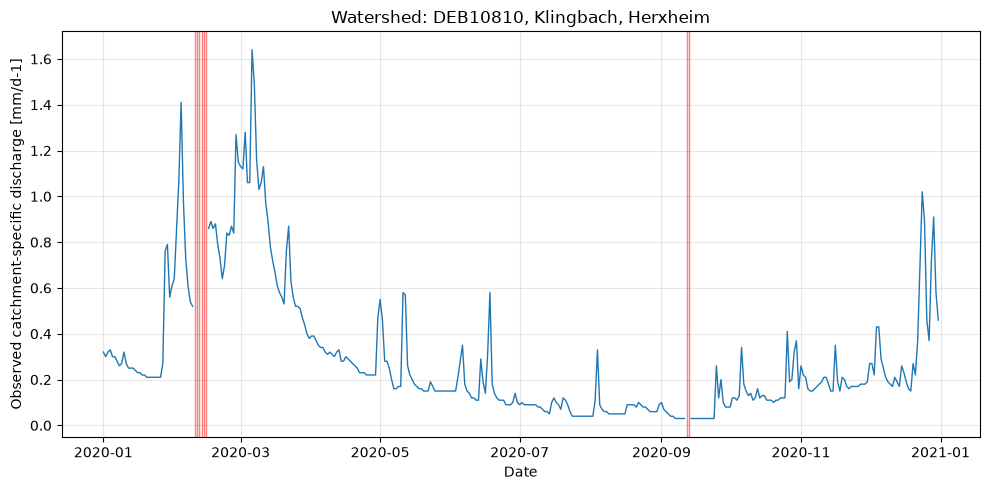

In [14]:
# Question 1.3
plot_flow_with_na(df=data.discharge, start="2020", end=None)

In [15]:
check_duplicated_dates(data=data)

Name: discharge
Duplicated dates: False
------------------------
Name: camel
Duplicated dates: False
------------------------
Name: agro_herxheimweyher
Duplicated dates: False
------------------------
Name: agro_steinweiler
Duplicated dates: False
------------------------


## 2. Catchment Description

In [16]:
from acp4.io.read_data import read_landuse_csv
from acp4.geo.io.read_data import read_catchment, read_gauge_station, create_weatherstation_points, read_dem_window
from acp4.geo.process.process_raster import expand_bbox
from acp4.geo.plot.plot import plot_watershed_stations
from acp4.geo.plot.plot import plot_landuse

In [19]:
# Catchment
gdf_watershed = read_catchment(
    filepath=config.catchment_gpkg_path,
    gauge_id=config.gauge_id
    )

# Gauge station
gdf_gauge = read_gauge_station(
    filepath=config.gauge_gpkg_path,
    gauge_id=config.gauge_id
)

# Agrometeo stations
gdf_stations = create_weatherstation_points(points=config.agrometeo_points)

# DEM
bbox = expand_bbox(gdf=gdf_watershed, extent=20_000)

dem, dem_transform, dem_crs = read_dem_window(
    filepath=config.dem_asc_path,
    bbox=bbox
    )

# CRS
gdf_watershed_25832 = gdf_watershed.to_crs(dem_crs)
gdf_gauge_25832 = gdf_gauge.to_crs(dem_crs)
gdf_stations_25832= gdf_stations.to_crs(dem_crs)

assert gdf_watershed_25832.crs == gdf_gauge_25832.crs == gdf_stations_25832.crs

Catchment Area [km²]: [100.45868705]


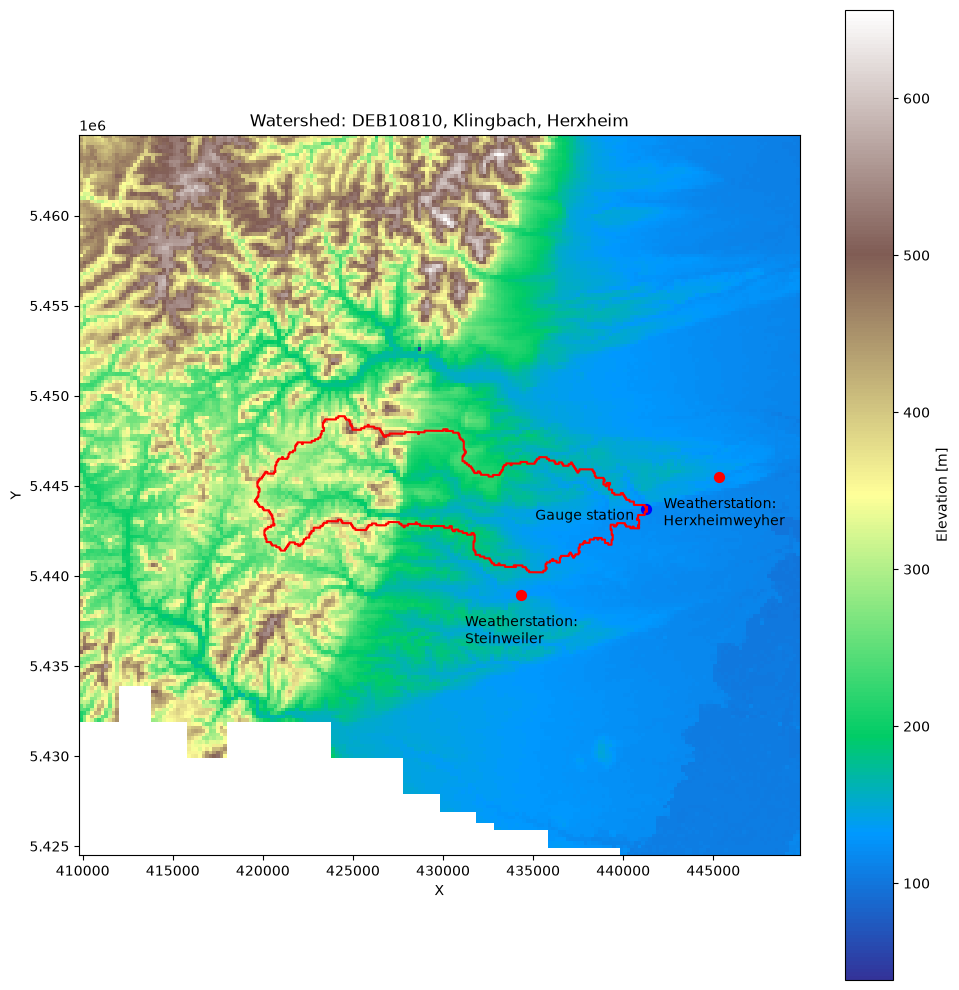

In [ ]:
# 2.1 What is the geographic location of the catchment? Where are the discharge
# gauging station and the precipitation stations located?

print(f"Catchment Area [km²]: {gdf_watershed_25832.area.to_numpy() / 1_000_000}")

plot_watershed_stations(
    points=gdf_stations_25832,
    gauge=gdf_gauge_25832,
    watershed=gdf_watershed_25832,
    dem=dem,
    dem_transform=dem_transform,
)

In [49]:
# 2.2 Coordinates and elevation range
elevation_ravel = np.ravel(dem.data)
elevation_ravel = elevation_ravel[np.where(elevation_ravel != -9999.0)]
elevation_ravel = np.round(elevation_ravel)

print(f"Elevation range [m]: {min(elevation_ravel)} - {max(elevation_ravel)}")

Elevation range [m]: 38.0 - 656.0


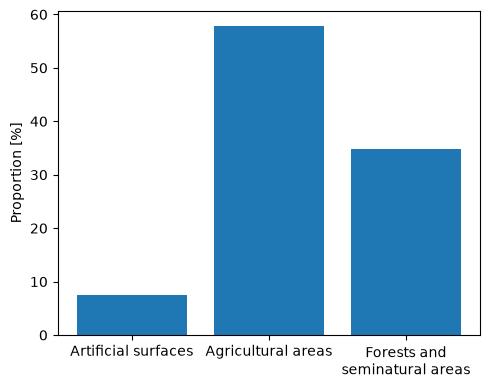

In [51]:
# 2.4 How is the land use split between agriculture, forests and artificial areas?
plot_landuse(filepath=config.landcover_csv_path)

## 3. Climate Analysis

In [8]:
from acp4.plot.plot import (
    plot_all_monthly_temp_hum_rad,
    print_minmax_month,
    plot_both_pet_comparison
)
from acp4.processing.process_data import summarize_data
from acp4.processing.pet import calculate_hargreaves_pet

In [9]:
# 3.1 (...) Which months are the warmest and coldest?
print_minmax_month(data=data)

camel
Coldest months:
Jan

Hottest months:
Jul
---------------------

agro_herxheimweyher
Coldest months:
Jan

Hottest months:
Jul
---------------------

agro_steinweiler
Coldest months:
Jan

Hottest months:
Jul
---------------------



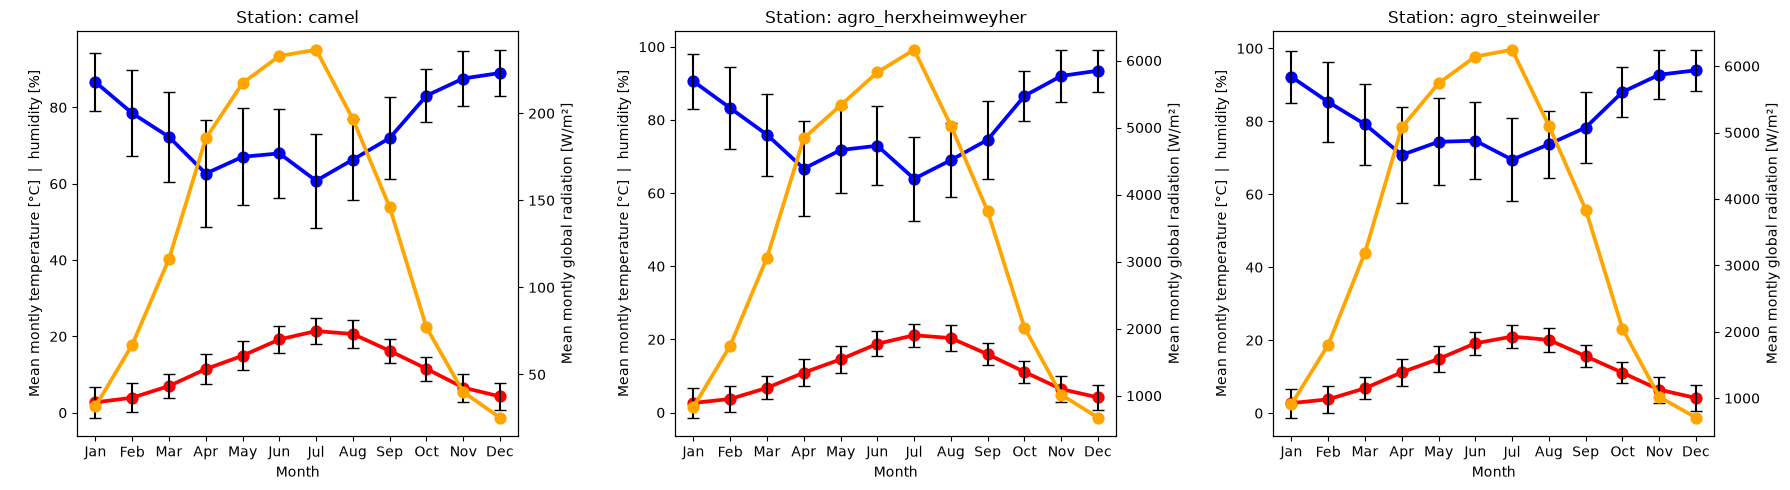

In [10]:
# 3.1 Calculate mean monthly temperature. (...) 
plot_all_monthly_temp_hum_rad(data=data)

In [11]:
# 3.5 Calculate PET using Hargreaves equation for one of your stations (...)
df_camel = read_camel_data(
    timeseries_dir=config.timeseries_simulated_dir, 
    gauge_id=config.gauge_id
)

df_pet_herxheimweyher = calculate_hargreaves_pet(
    df=data.agro_herxheimweyher
)

df_pet_steinweiler = calculate_hargreaves_pet(
    df=data.agro_steinweiler
)

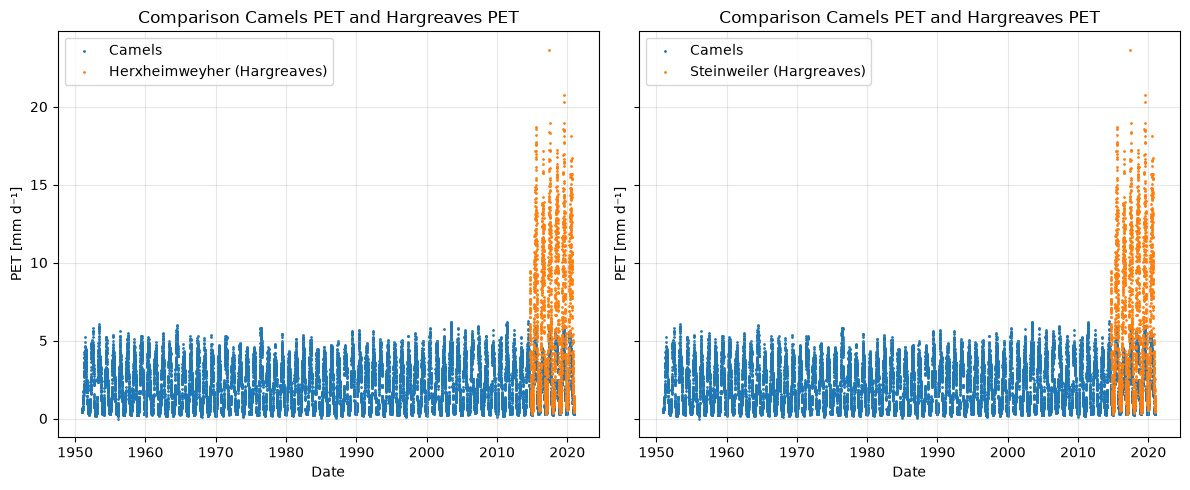

In [12]:
# 3.5 (...) and compare to the CAMELS PET value.
plot_both_pet_comparison(
    camel_pet=df_camel["pet_hargreaves"],
    herxheimweyher_pet=df_pet_herxheimweyher,
    steinweiler_pet=df_pet_herxheimweyher
)

## 4. Rainfall Analysis

In [66]:
from acp4.processing.process_data import agg_all_annually_sum, agg_all_monthly_precip_sum
from acp4.plot.plot import (
    plot_all_annual_precip_sum, 
    plot_all_monthly_precip_sum,
    plot_all_extreme_rainfall_events
)

Vieljähriger Mittelwert: 788.9 mm
https://www.dwd.de/DE/leistungen/zeitreihen/zeitreihen.html?nn=480164

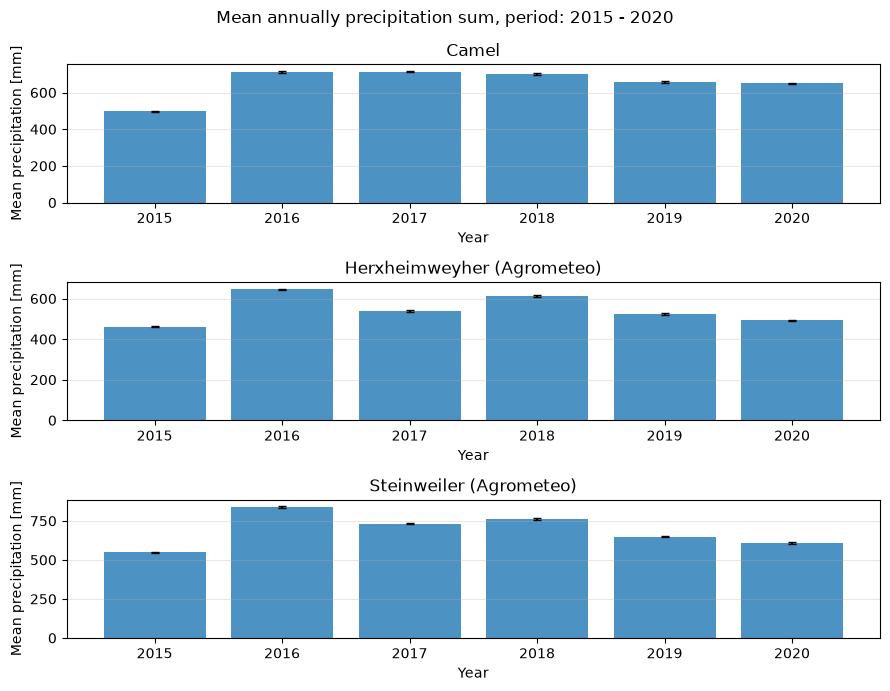

In [ ]:
# 4.1 Describe the annual rainfall regime (annual mean sum, ...)
# 4.2 Plot the annual average sum of rainfall over time.

annual_mean_sum = agg_all_annually_sum(data=data)    
plot_all_annual_precip_sum(data=annual_mean_sum)

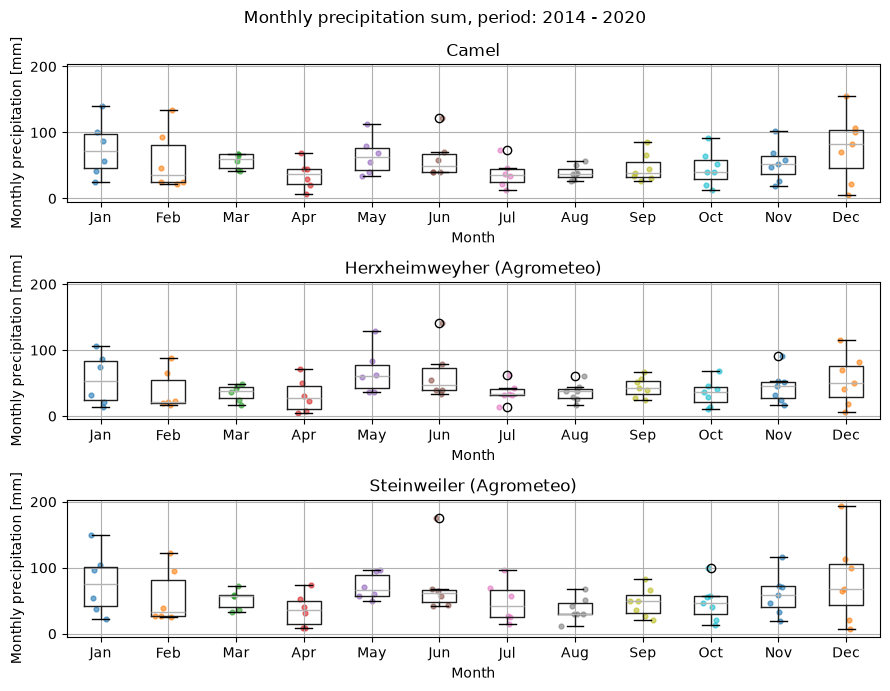

In [22]:
# 4.1 Describe the annual rainfall regime ( (...), seasonal distribution)
monthly_precip_sum = agg_all_monthly_precip_sum(data=data)
plot_all_monthly_precip_sum(data=monthly_precip_sum)

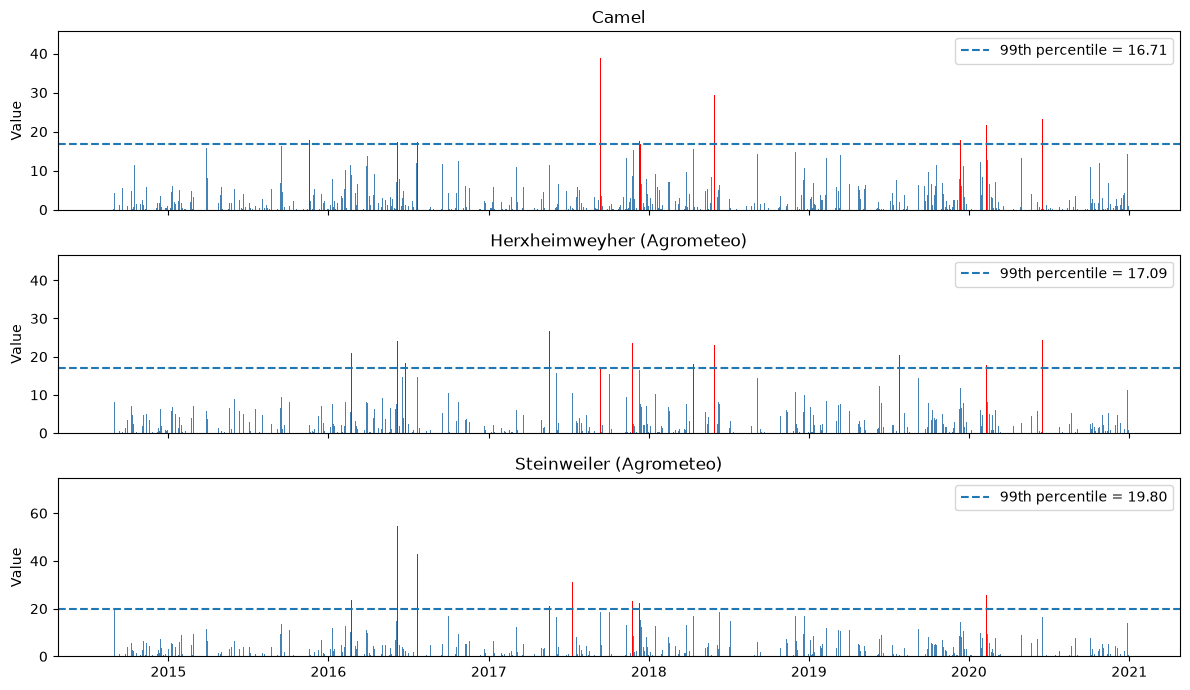

In [ ]:
# 4.4 Identify extreme rainfall events (>99th percentile).
plot_all_extreme_rainfall_events(data=data)

## 5. Streamflow Analysis

In [103]:
import pymannkendall as mk

from acp4.processing.process_data import (
    agg_annually_discharge,
    agg_monthly_discharge_mean,
    calc_trend_metrics,
    subset_high_low_values
)
from acp4.plot.plot import (
    plot_annual_discharge_sum,
    plot_monthly_discharge_mean,
    plot_annual_max_flow_days,
    plot_rating_curve,
    plot_discharge_trends,
    plot_high_low_percentile_flows
)

from acp4.processing.process_data import agg_annually_discharge

In [134]:
# Note: Here i reload the data which is unaligned and therefore provides more data from the past
df_discharge, _ = read_camel_data(
    timeseries_dir=config.timeseries_dir, 
    gauge_id=config.gauge_id
)

df_discharge.dropna(inplace=True)

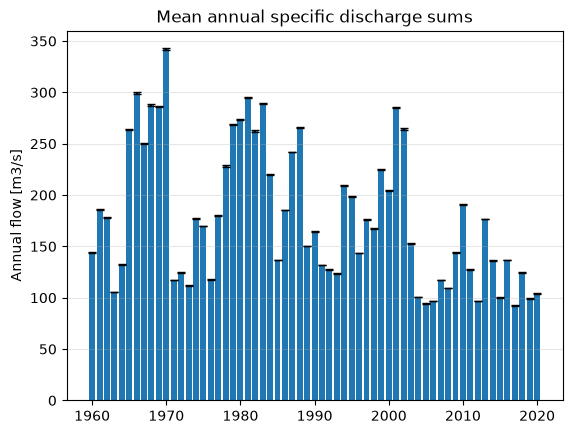

In [135]:
# 5.1. What are the average annual flows? Use specific discharge in mm/d to calculate
# average annual sums that are comparable to the annual precipitation sums.
annual_discharge_agg = agg_annually_discharge(df=df_discharge["discharge_spec_obs"])
plot_annual_discharge_sum(annual_discharge_agg)

In [136]:
# 5.2. What is the mean daily flow, as well as the highest and lowest recorded flows?
# [both for m3/s and observed water level]3
print("Specific Discharge [m3/s]:")
print(f"Mean daily flow: {df_discharge['discharge_spec_obs'].mean().round(4)}")
print(f"Min daily flow: {df_discharge['discharge_spec_obs'].min()}")
print(f"Max daily flow: {df_discharge['discharge_spec_obs'].max()}")

print("-----------------------------")
print("Water level [cm]:")
print(f"Mean daily waterlevel: {df_discharge['water_level_obs'].mean().round(2)}")
print(f"Min daily waterlevel: {df_discharge['water_level_obs'].min()}")
print(f"Max daily waterlevel: {df_discharge['water_level_obs'].max()}")

Specific Discharge [m3/s]:
Mean daily flow: 0.4896
Min daily flow: 0.02
Max daily flow: 5.66
-----------------------------
Water level [cm]:
Mean daily waterlevel: 29.36
Min daily waterlevel: 1.0
Max daily waterlevel: 134.0


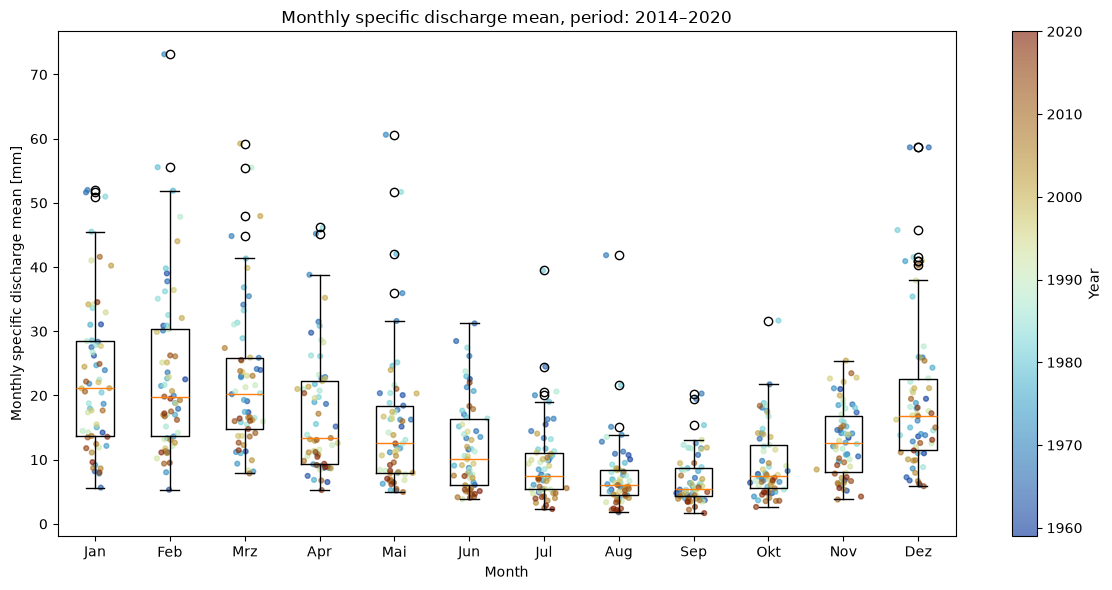

In [145]:
# 5.3. Calculate mean monthly flow. How does streamflow vary throughout the year?
# Does rainfall seasonality correspond to streamflow seasonality? If not, what
# processes could explain the differences?
monthly_discharge_mean = agg_monthly_discharge_mean(df=df_discharge['discharge_spec_obs'])
plot_monthly_discharge_mean(df=monthly_discharge_mean)

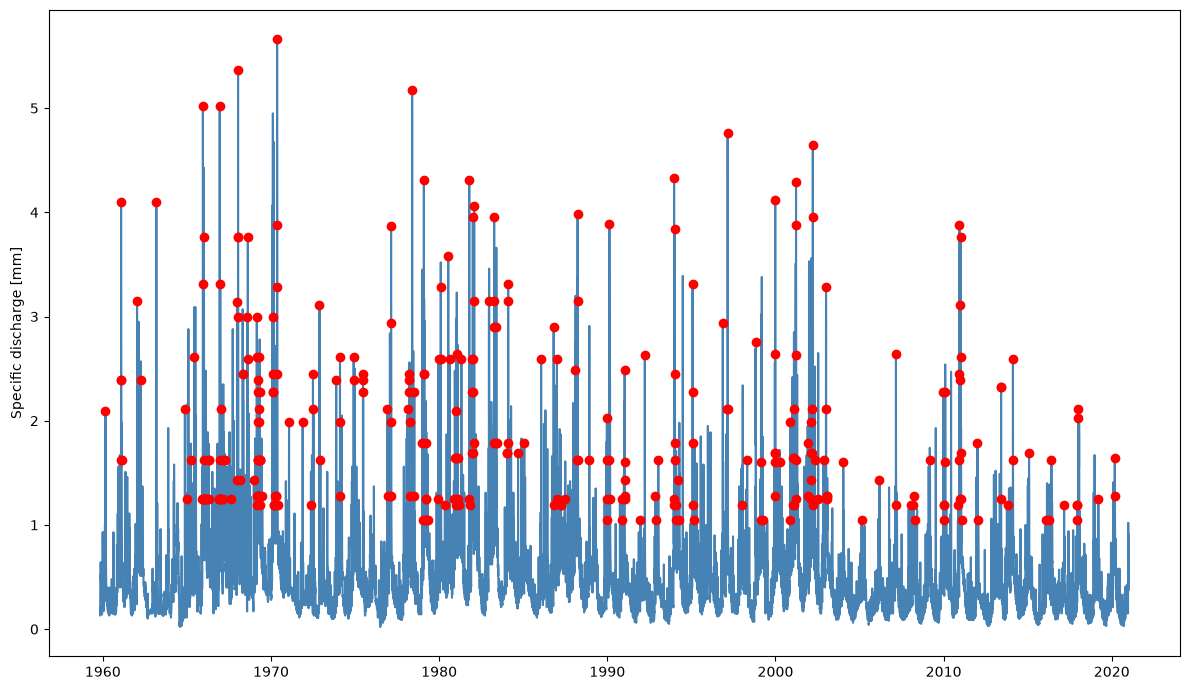

In [146]:
# 5.4. Identify annual maximum flow days.
plot_annual_max_flow_days(
    df=df_discharge['discharge_spec_obs'], 
    max_flows=annual_discharge_agg['max']
)

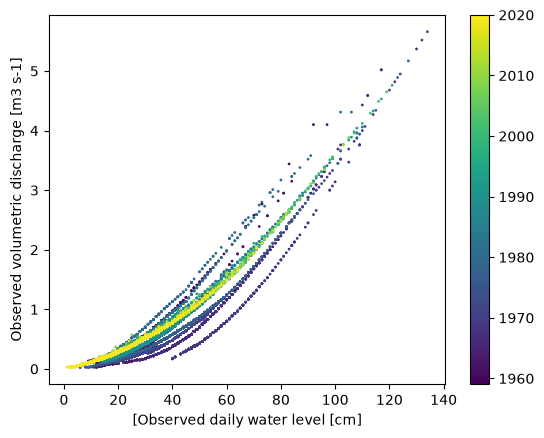

In [ ]:
# 5.5. Plot the stage discharge relationship.
plot_rating_curve(df=df_discharge)

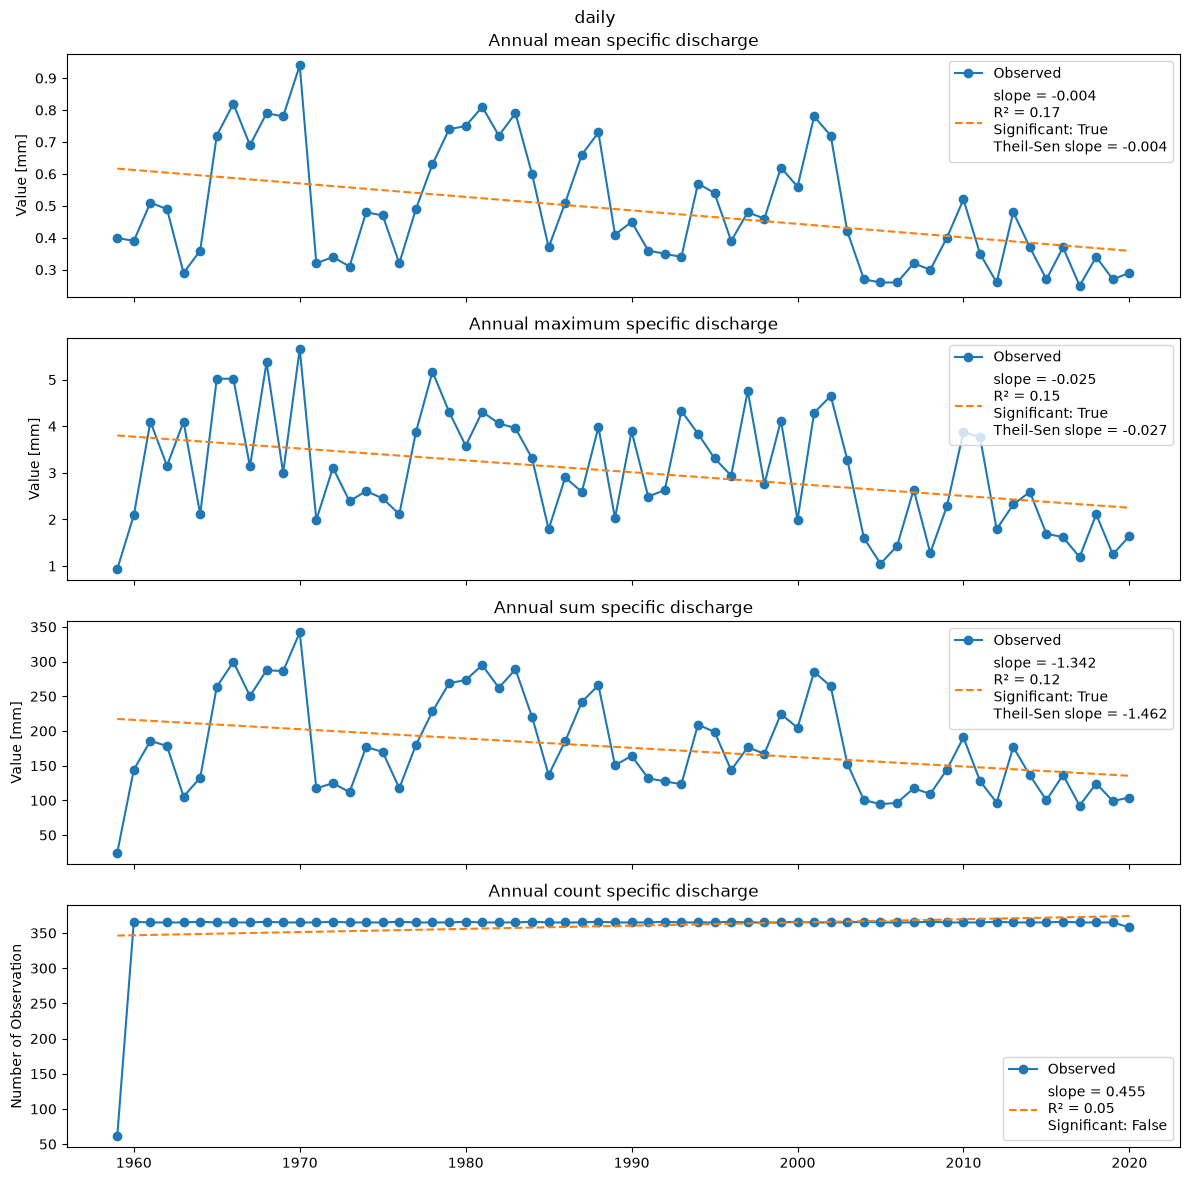

c:\Users\Administrator\Desktop\Uni Landau\Master\4. Semester\ACP4\ACP4\.venv\Lib\site-packages\pymannkendall\pymannkendall.py:60: RuntimeWarning: invalid value encountered in divide
  return acov[:nlags+1]/acov[0]


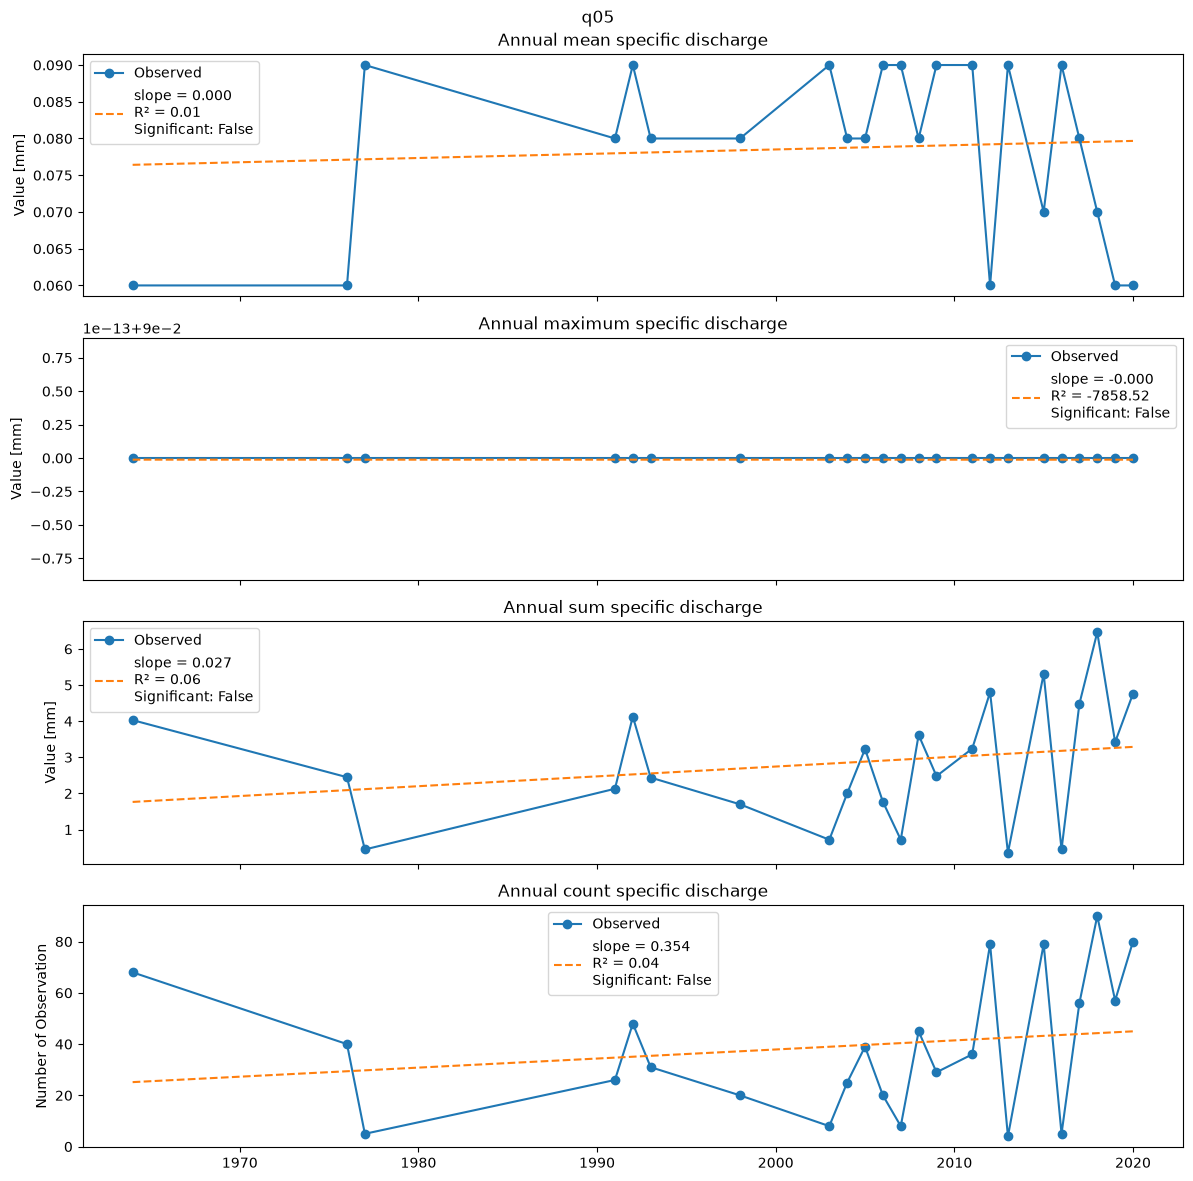

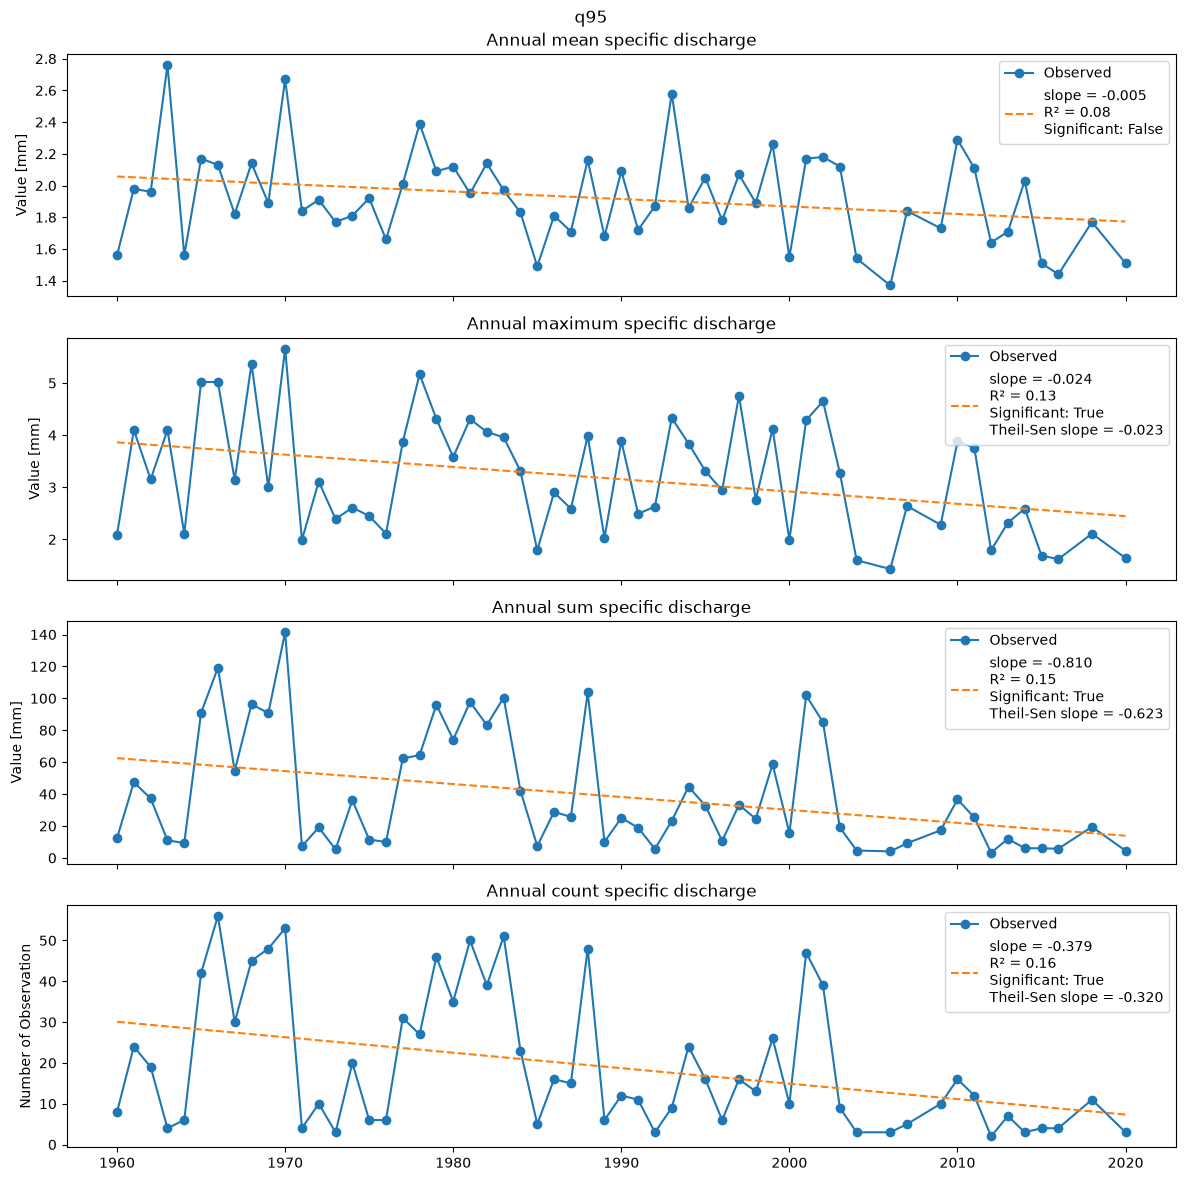

In [147]:
# 
subset = subset_high_low_values(df=df_discharge['discharge_spec_obs'])

discharges = {
    "daily": df_discharge['discharge_spec_obs'],
    "q05": subset["Q05"],
    "q95": subset["Q95"],
}

annually_discharge_agg = {}

for key, df in discharges.items():
    aggregated = agg_annually_discharge(df=df, complete_years_only=False)
    aggregated = aggregated.dropna()

    annually_discharge_agg[key] = aggregated


for key, df in annually_discharge_agg.items():
    plot_discharge_trends(df=df, suptitle=key)

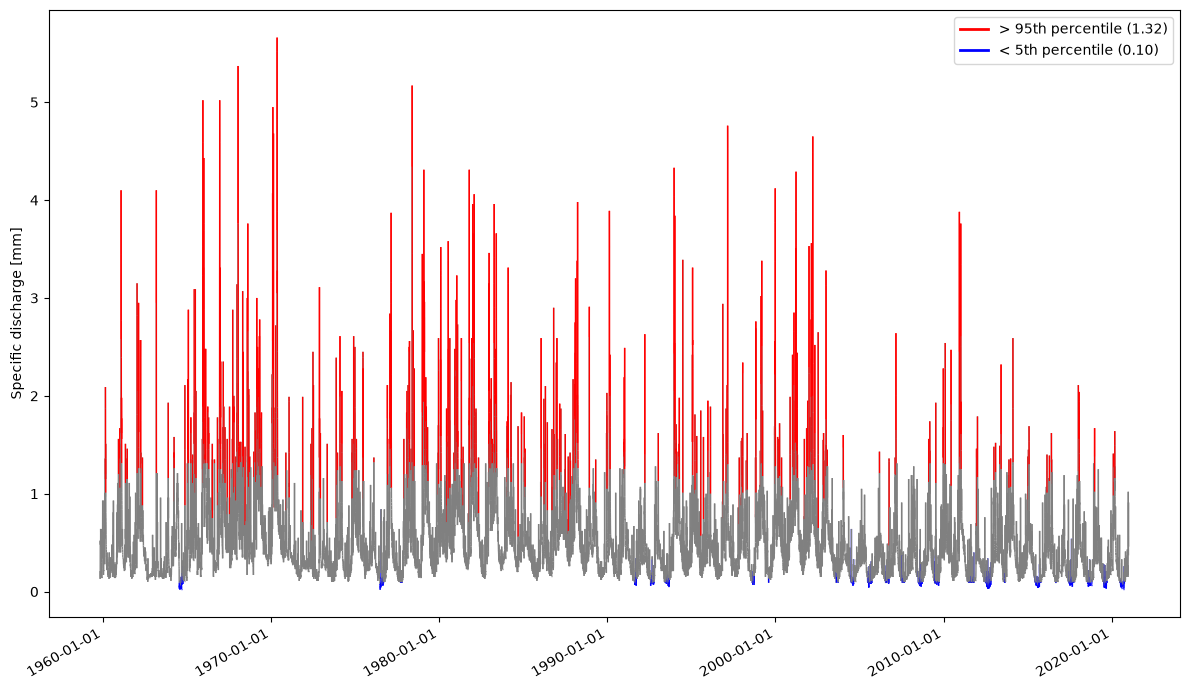

In [148]:
plot_high_low_percentile_flows(df=df_discharge['discharge_spec_obs'])

### Bug in pymannkendall.py, line 189, seasonal_sens_slope()

Maybe implementation from R is further step to get more result parmas:
https://github.com/cran/trend/blob/master/R/sens.slope.R

In [61]:
def __sens_estimator(x):
    idx = 0
    n = len(x)
    d = np.ones(int(n*(n-1)/2))

    for i in range(n-1):
        j = np.arange(i+1,n)
        d[idx : idx + len(j)] = (x[j] - x[i]) / (j - i)
        idx = idx + len(j)
        
    return d

def __preprocessing(x):
    x = np.asarray(x).astype(float)
    dim = x.ndim
    
    if dim == 1:
        c = 1
        
    elif dim == 2:
        (n, c) = x.shape
        
        if c == 1:
            dim = 1
            x = x.flatten()
         
    else:
        print('Please check your dataset.')
        
    return x, c

In [ ]:
x_old = annually_discharge_agg['max']
period=12

x, c = __preprocessing(x=x_old)
n = len(x)

print(x_old.shape)
print(x.shape)

if x.ndim == 1:
    if np.mod(n,period) != 0:
        x = np.pad(x,(0,period - np.mod(n,period)), 'constant', constant_values=(np.nan,))

    x = x.reshape(int(len(x)/period),period)

print(x_old.shape)
print(x.shape)

result_old = np.median(np.arange(x_old.size)[~np.isnan(x_old.to_numpy().flatten())])
result_new = np.median(np.arange(x.size)[~np.isnan(x.flatten())])

print(result_old)
print(result_new)